In [1]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [2]:
# loading the dataset
df = pd.read_csv("../data/working.csv")

df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [3]:
#same features like before in regression
selected_features = [
    "URLLength",
    "IsDomainIP",
    "TLD",
    "NoOfDegitsInURL",
    "NoOfOtherSpecialCharsInURL",
    "IsHTTPS",
    "DomainLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "label"
]

df = df[selected_features]

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (235795, 10)


,URLLength,IsDomainIP,TLD,NoOfDegitsInURL,NoOfOtherSpecialCharsInURL,IsHTTPS,DomainLength,NoOfSubDomain,HasObfuscation,label
0,31,0,com,0,1,1,24,1,0,1
1,23,0,de,0,2,1,16,1,0,1
2,29,0,uk,0,2,1,22,2,0,1
3,26,0,com,0,1,1,19,1,0,1
4,33,0,org,0,1,1,26,1,0,1


In [4]:
# missing values in dataset
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

URLLength                     0
IsDomainIP                    0
TLD                           0
NoOfDegitsInURL               0
NoOfOtherSpecialCharsInURL    0
IsHTTPS                       0
DomainLength                  0
NoOfSubDomain                 0
HasObfuscation                0
label                         0
dtype: int64

Total missing values: 0


label
1    134850
0    100945
Name: count, dtype: int64


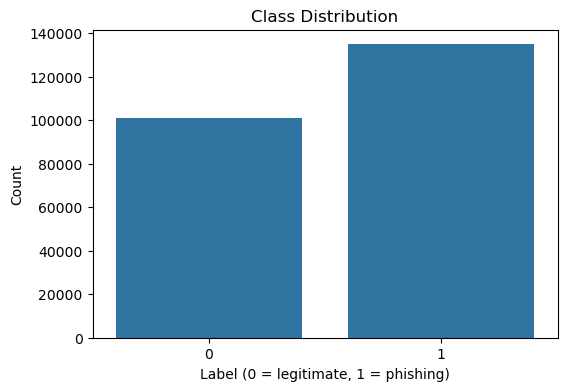

In [5]:
# checking how many phishing and how many legitimate domains are within the dataset
print(df["label"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Class Distribution")
plt.xlabel("Label (0 = legitimate, 1 = phishing)")
plt.ylabel("Count")
plt.show()

In [6]:
# splitting features from the target
X = df.drop("label", axis=1)
y = df["label"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (235795, 9)
Target vector shape: (235795,)


In [7]:
# top 10 most prevalent TLDs
top_tlds = X["TLD"].value_counts().nlargest(10).index
print(top_tlds.values)

# replace all other TLDs with "other"
X["TLD"] = X["TLD"].apply(lambda x: x if x in top_tlds else "other")

# check number of unique categories
print("Unique TLD categories:", X["TLD"].nunique())

# encode the TLD column and remove other - all 'false' automatically means other
X = pd.get_dummies(X, columns=["TLD"], drop_first=True)

print("Feature matrix after encoding:", X.shape)
X.head()

['com' 'org' 'net' 'app' 'uk' 'co' 'io' 'de' 'ru' 'au']
Unique TLD categories: 11
Feature matrix after encoding: (235795, 18)


,URLLength,IsDomainIP,NoOfDegitsInURL,NoOfOtherSpecialCharsInURL,IsHTTPS,DomainLength,NoOfSubDomain,HasObfuscation,TLD_au,TLD_co,TLD_com,TLD_de,TLD_io,TLD_net,TLD_org,TLD_other,TLD_ru,TLD_uk
0,31,0,0,1,1,24,1,0,False,False,True,False,False,False,False,False,False,False
1,23,0,0,2,1,16,1,0,False,False,False,True,False,False,False,False,False,False
2,29,0,0,2,1,22,2,0,False,False,False,False,False,False,False,False,False,True
3,26,0,0,1,1,19,1,0,False,False,True,False,False,False,False,False,False,False
4,33,0,0,1,1,26,1,0,False,False,False,False,False,False,True,False,False,False


In [8]:
# splitting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (188636, 18)
Test set shape: (47159, 18)


In [9]:
#training the model
model_dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

model_dt.fit(X_train, y_train)

print("trained successfully")

trained successfully


In [10]:
y_pred_dt = model_dt.predict(X_test)

print("Predictions created.")

Predictions created.


In [11]:
# evaluation
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Decision Tree Performance:
Accuracy : 0.9873
Precision: 0.9859
Recall   : 0.9920
F1 Score : 0.9889


Confusion Matrix:
[[19807   382]
 [  216 26754]]


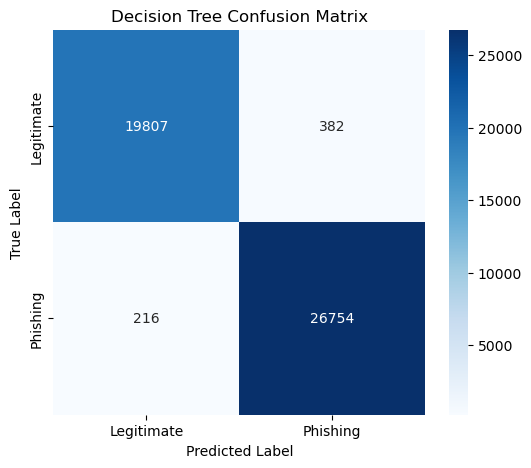

In [12]:
# creating a confusion matrix and graph
cm = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legitimate", "Phishing"],
            yticklabels=["Legitimate", "Phishing"])
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [13]:
print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=["Legitimate", "Phishing"]))

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99     20189
    Phishing       0.99      0.99      0.99     26970

    accuracy                           0.99     47159
   macro avg       0.99      0.99      0.99     47159
weighted avg       0.99      0.99      0.99     47159



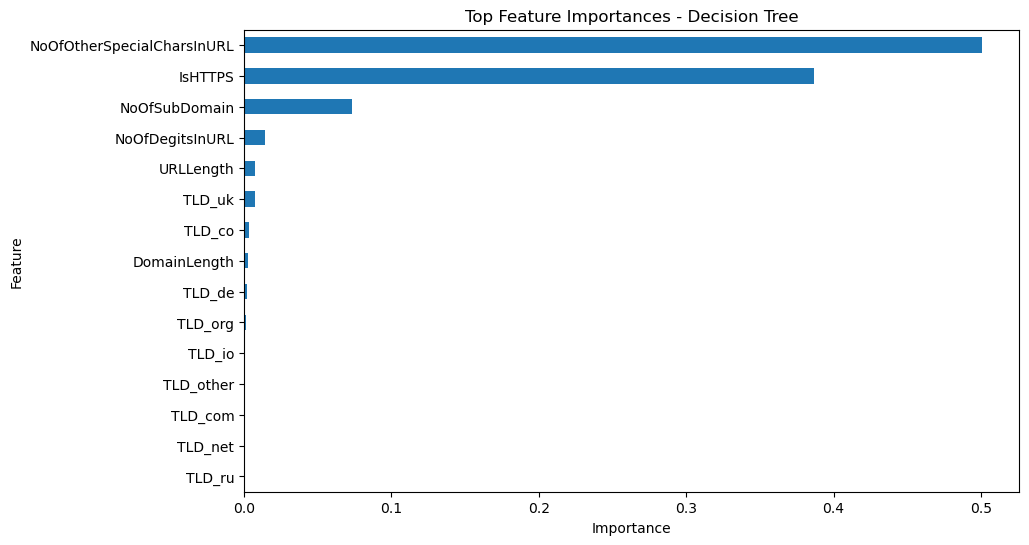

In [15]:
# Feature importance
# extracting feature importances from decision tree
feature_importances = pd.Series(
    model_dt.feature_importances_,
    index=X.columns
)

# sort features by importance
feature_importances = feature_importances.sort_values(ascending=False)

# display the most important features
feature_importances.head(15)

top_n = 15
top_features = feature_importances.head(top_n)

plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind="barh")
plt.title("Top Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

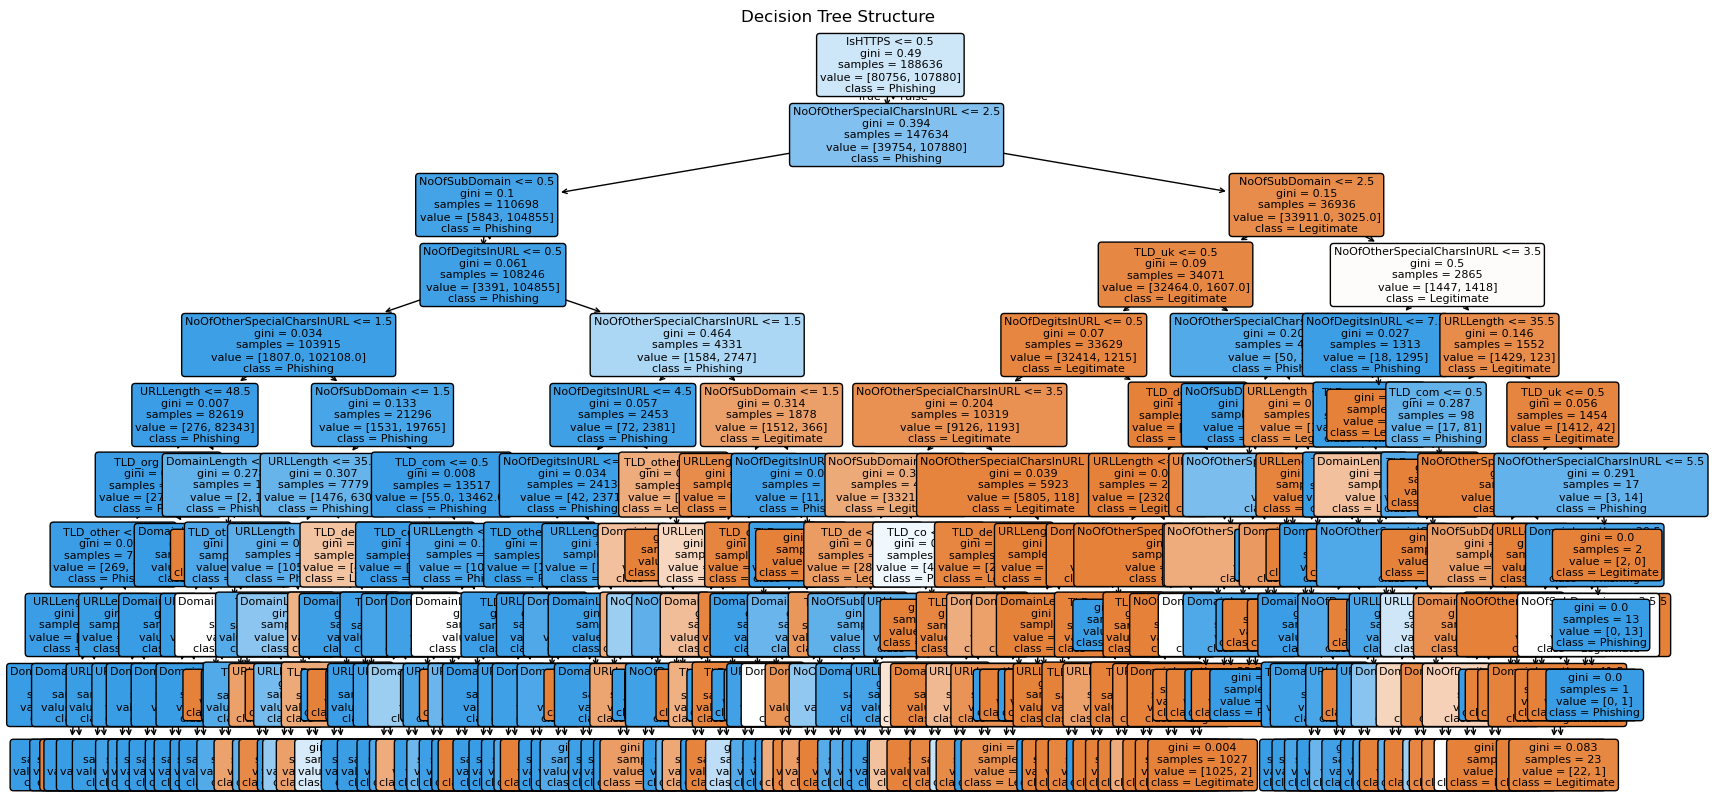

In [16]:
# Visualising the tree
plt.figure(figsize=(20,10))
plot_tree(
    model_dt,
    feature_names=X.columns,
    class_names=["Legitimate", "Phishing"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Structure")
plt.show()

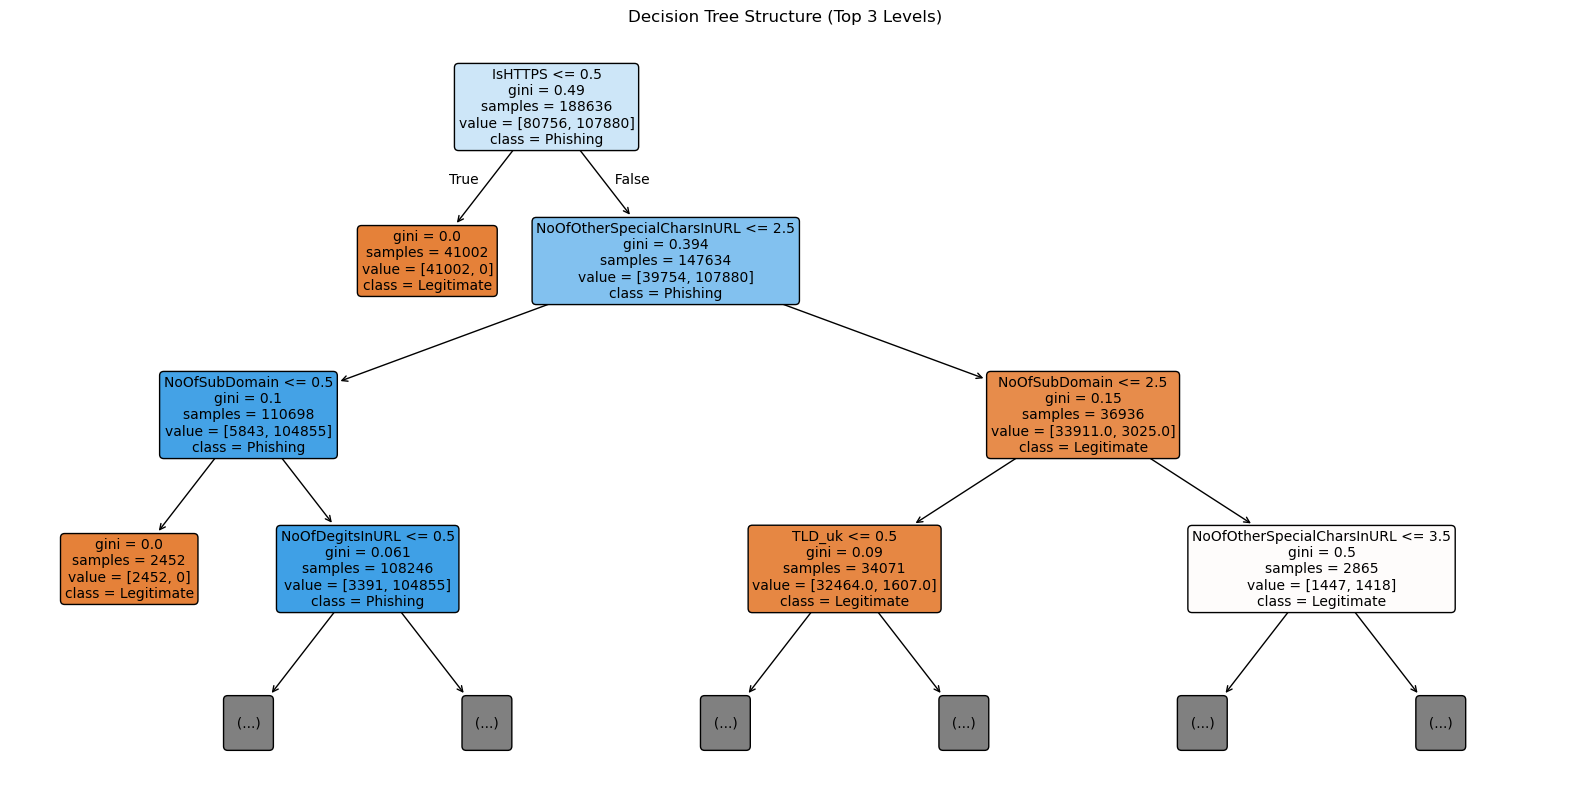

In [17]:
plt.figure(figsize=(20,10))
plot_tree(
    model_dt,
    feature_names=X.columns,
    class_names=["Legitimate", "Phishing"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title("Decision Tree Structure (Top 3 Levels)")
plt.show()

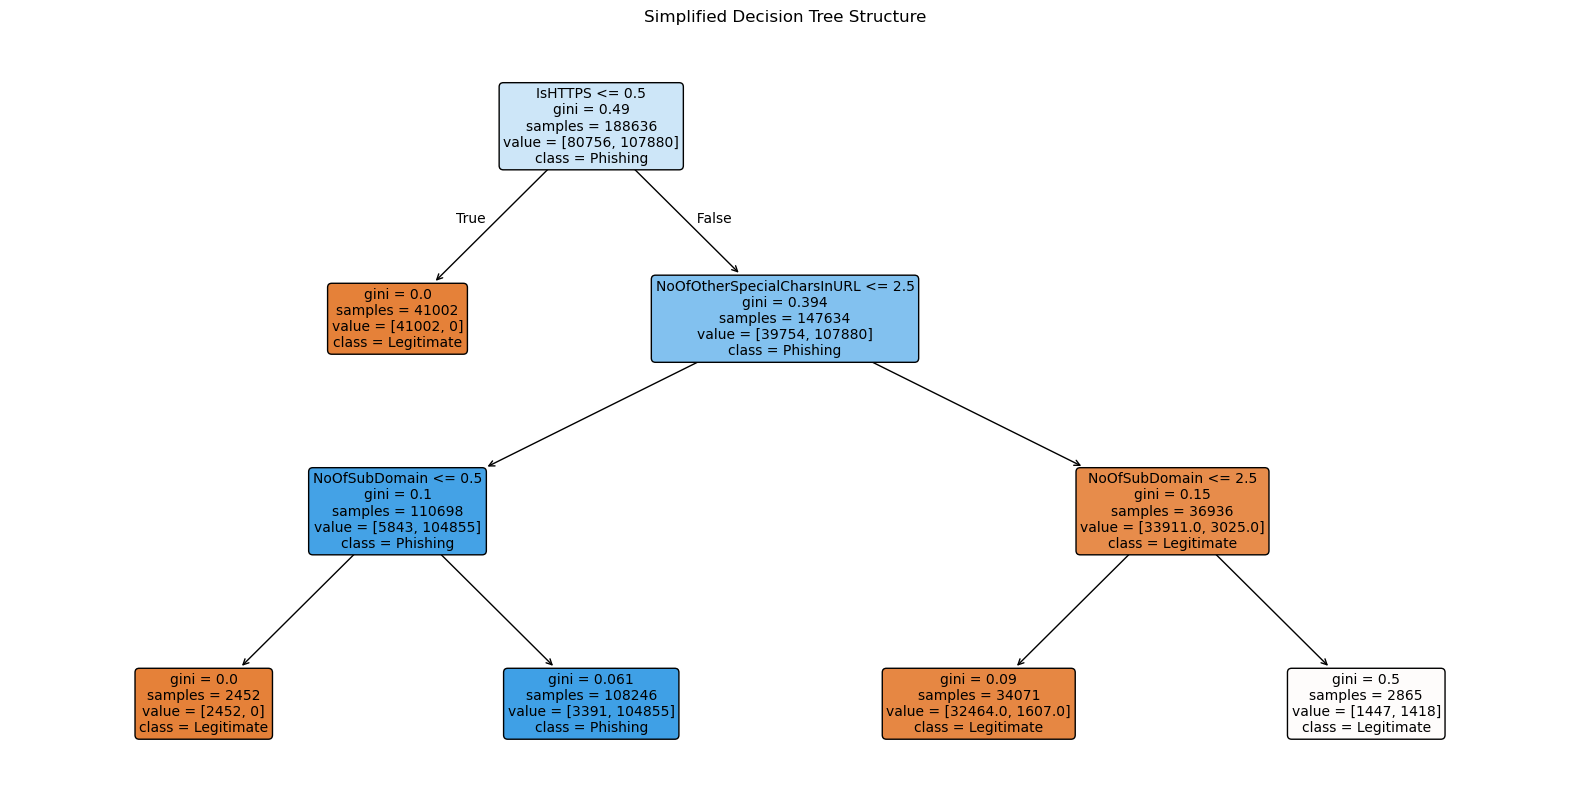

In [18]:
model_dt_small = DecisionTreeClassifier(max_depth=3, random_state=42)
model_dt_small.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(
    model_dt_small,
    feature_names=X.columns,
    class_names=["Legitimate", "Phishing"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Simplified Decision Tree Structure")
plt.show()

In [19]:
joblib.dump(model_dt, "../models/decision_tree_model.pkl")
print("saved")


saved


In [20]:
results_df = pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
])

results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.987319,0.985923,0.991991,0.988948
